3. Engajamento nas atividades (IEG): O grau de engajamento dos
alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e
do ponto de virada (IPV)?

4. Autoavaliação (IAA): As percepções dos alunos sobre si mesmos
(IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

In [87]:
url = "https://raw.githubusercontent.com/vbomura/tc5/main/Codigos/base_anos_limpo.xlsx"
dfBaseAnosLimpos = pd.read_excel(url)

In [88]:
dfBaseAnosLimpos

,ra,fase_original,turma,nome_anonimizado,ano_nasc_original,idade_original,genero,ano_ingresso,instituicao_de_ensino,pedra,...,ipv,ian,fase_ideal_original,defasagem,ano_aba,ano_nascimento,fase,fase_ideal,ipp,idade
0,RA-1,7,A,Aluno-1,2003,19,Feminino,2016,Escola Pública,Quartzo,...,7.278,5.0,Fase 8 (Universitários),-1,2022,2003,FASE 7,FASE 8,NaN,19
1,RA-2,7,A,Aluno-2,2005,17,Feminino,2017,Rede Decisão,Ametista,...,6.778,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,FASE 7,NaN,17
2,RA-3,7,A,Aluno-3,2005,17,Feminino,2016,Rede Decisão,Ágata,...,7.556,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,FASE 7,NaN,17
3,RA-4,7,A,Aluno-4,2005,17,Masculino,2017,Rede Decisão,Quartzo,...,5.278,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,FASE 7,NaN,17
4,RA-5,7,A,Aluno-5,2005,17,Feminino,2016,Rede Decisão,Ametista,...,7.389,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,FASE 7,NaN,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2840,RA-291,7E,7E,Aluno-291,2009-01-17 00:00:00,15,Masculino,2022,Privada - Programa de Apadrinhamento,Ametista,...,7.500,10.0,Fase 5 (1° EM),2,2024,2009,FASE 7,FASE 5,7.5,15
2841,RA-86,7E,7E,Aluno-86,2006-10-04 00:00:00,18,Masculino,2021,Privada *Parcerias com Bolsa 100%,Ametista,...,7.500,10.0,Fase 7 (3° EM),0,2024,2006,FASE 7,FASE 7,7.5,18
2842,RA-143,7E,7E,Aluno-143,2009-08-01 00:00:00,15,Masculino,2021,Privada - Programa de Apadrinhamento,Ametista,...,7.500,10.0,Fase 5 (1° EM),2,2024,2009,FASE 7,FASE 5,7.5,15
2843,RA-166,7E,7E,Aluno-166,2008-06-03 00:00:00,16,Masculino,2021,Privada *Parcerias com Bolsa 100%,Topázio,...,7.500,10.0,Fase 6 (2° EM),1,2024,2008,FASE 7,FASE 6,7.5,16


In [89]:
dfBaseAnosLimpos['fase'].unique()

array(['FASE 7', 'FASE 6', 'FASE 5', 'FASE 4', 'FASE 3', 'FASE 2',
       'FASE 1', 'ALFA'], dtype=object)

## Questão 3

3. Engajamento nas atividades (IEG): O grau de engajamento dos
alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e
do ponto de virada (IPV)?

In [90]:
colunas3 = ['ieg', 'ida', 'ipv']

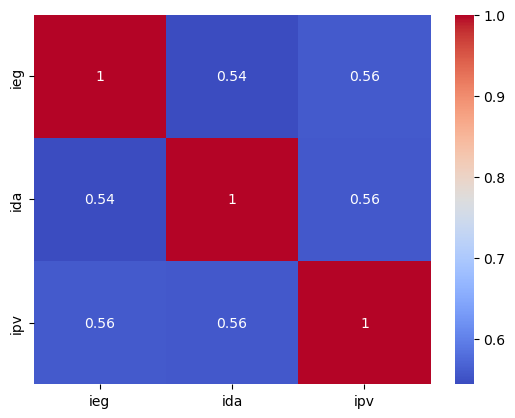

In [91]:
# Criar correlação entre as colunas
sns.heatmap(dfBaseAnosLimpos[colunas3].corr(), annot=True, cmap='coolwarm')
plt.show()

In [92]:
# Correlação de Pearson
corr_ieg_ida = dfBaseAnosLimpos['ieg'].corr(dfBaseAnosLimpos['ida'])
corr_ieg_ipv = dfBaseAnosLimpos['ieg'].corr(dfBaseAnosLimpos['ipv'])

print(f"Correlação IEG x IDA: {corr_ieg_ida:.2f}")

print(f"Correlação IEG x IPV: {corr_ieg_ipv:.2f}")

Correlação IEG x IDA: 0.54
Correlação IEG x IPV: 0.56


📈 Correlação (IEG x IDA) e (IEG x IPV)

IEG x IDA (0.54): Existe uma correlação positiva moderada. Isso indica que, conforme o engajamento aumenta, a tendência é que o desempenho acadêmico também suba.

IEG x IPV (0.56): A relação com o Ponto de Virada é ligeiramente mais forte. Isso sugere que o engajamento tem um papel crucial em levar o aluno ao estágio onde ele "vira a chave" em seu aprendizado.

As variáveis estão alinhadas e não crescem de forma isolada.

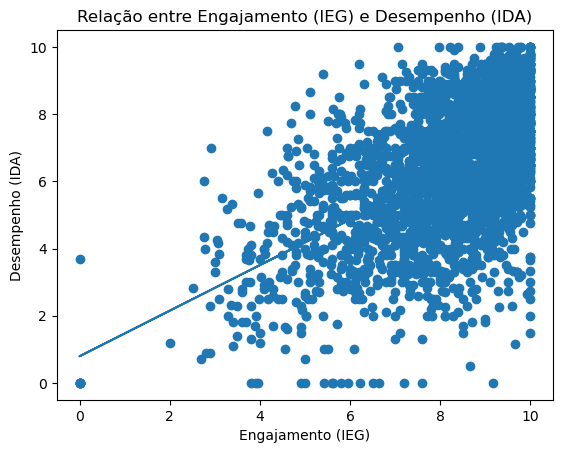

In [93]:
# ---------- FUNÇÃO PARA SCATTER COM REGRESSÃO ----------
def scatter_reg(x, y, xlabel, ylabel, title):
    plt.figure()
    plt.scatter(x, y)
    
    # linha de regressão
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m*x + b)
    
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

# Gráfico IEG x IDA
scatter_reg(
    dfBaseAnosLimpos['ieg'], dfBaseAnosLimpos['ida'],
    'Engajamento (IEG)',
    'Desempenho (IDA)',
    'Relação entre Engajamento (IEG) e Desempenho (IDA)'
)


📈 Relação entre Engajamento (IEG) e Desempenho (IDA)

Observa-se uma tendência positiva:

À medida que o IEG aumenta, o IDA tende a aumentar.

Nota-se uma grande densidade de pontos no quadrante superior direito, indicando que a maioria dos alunos que se engajam muito (IEG próximo a 10) atinge desempenhos elevados.

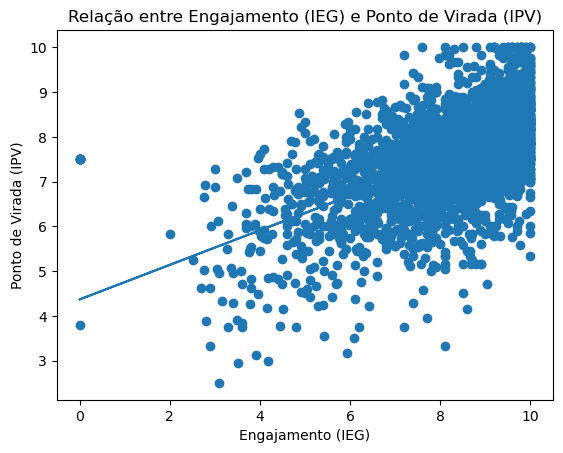

In [94]:
# Gráfico IEG x IPV
scatter_reg(
    dfBaseAnosLimpos['ieg'], dfBaseAnosLimpos['ipv'],
    'Engajamento (IEG)',
    'Ponto de Virada (IPV)',
    'Relação entre Engajamento (IEG) e Ponto de Virada (IPV)'
)

📈 Relação entre Engajamento (IEG) e Ponto de Virada (IPV)

A tendência positiva também está presente, porém mais concentrada.

À medida que o IEG cresce, os valores de IPV se elevam e se estabilizam em patamares mais altos.

A dispersão é menor do que no gráfico IEG × IDA, sugerindo relação mais consistente. Isso reforça que é muito difícil um aluno atingir o "Ponto de Virada" sem um nível mínimo de engajamento (poucos pontos de IPV alto com IEG baixo).


## 🎯 Resposta final questão 3:

✅ Sim. Conseguimos identificar uma relação positiva.

O engajamento dos alunos (IEG) apresenta relação positiva com o desempenho acadêmico:
  - (IDA) indicando que níveis mais altos de engajamento tendem a estar associados a melhores resultados.
  - (IPV) sugerindo que alunos mais engajados tendem a alcançar marcos importantes de evolução acadêmica com maior consistência.

Não é um fator isolado: Embora a correlação seja de 0.54 - 0.56, ela não é total (1.0). Isso significa que o engajamento é um pilar fundamental, mas outros fatores também compõem o desempenho final.

Os gráficos mostram que o engajamento acima de 7.5 é onde se concentra a maior parte dos alunos com IDA e IPV de excelência.

## Questão 4:

4. Autoavaliação (IAA): As percepções dos alunos sobre si mesmos
(IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

In [95]:
mask_iaa_invalido = (dfBaseAnosLimpos["iaa"] == 0) | (dfBaseAnosLimpos["iaa"].isna())
df_iaa_invalido = dfBaseAnosLimpos[mask_iaa_invalido]
qtd_invalido = mask_iaa_invalido.sum()
print(f"Quantidade de registros com iaa = 0 ou nulo: {qtd_invalido}")

Quantidade de registros com iaa = 0 ou nulo: 245


Retirado valores nulos ou 0 da analise das informações para a questão 4

In [96]:
df_Questao4 = dfBaseAnosLimpos[~mask_iaa_invalido]

df_Questao4.shape[0]

2600

In [97]:
# df_Questao4[['iaa', 'ida', 'ieg']].info()
df_Questao4[['iaa', 'ida', 'ieg']].describe()

,iaa,ida,ieg
count,2600.000000,2600.000000,2600.000000
mean,8.673506,6.420737,8.269530
std,1.008156,1.955795,1.553881
min,1.700000,0.000000,0.000000
25%,8.002000,5.166667,7.525253
50%,8.850000,6.700000,8.700000
75%,9.500000,7.900000,9.438567
max,10.002000,10.000000,10.000000


In [98]:
colunas4 = ['iaa', 'ida', 'ieg','fase']

In [99]:
df_Questao4[colunas4]

,iaa,ida,ieg,fase
0,8.300,4.000000,4.100000,FASE 7
1,8.800,6.800000,5.200000,FASE 7
3,8.800,5.000000,4.500000,FASE 7
4,7.900,5.200000,8.600000,FASE 7
5,7.900,3.300000,4.500000,FASE 7
...,...,...,...,...
2840,8.751,6.166667,9.737667,FASE 7
2841,6.667,5.483333,9.704333,FASE 7
2842,10.002,2.633333,9.920000,FASE 7
2843,8.334,8.266667,9.246000,FASE 7


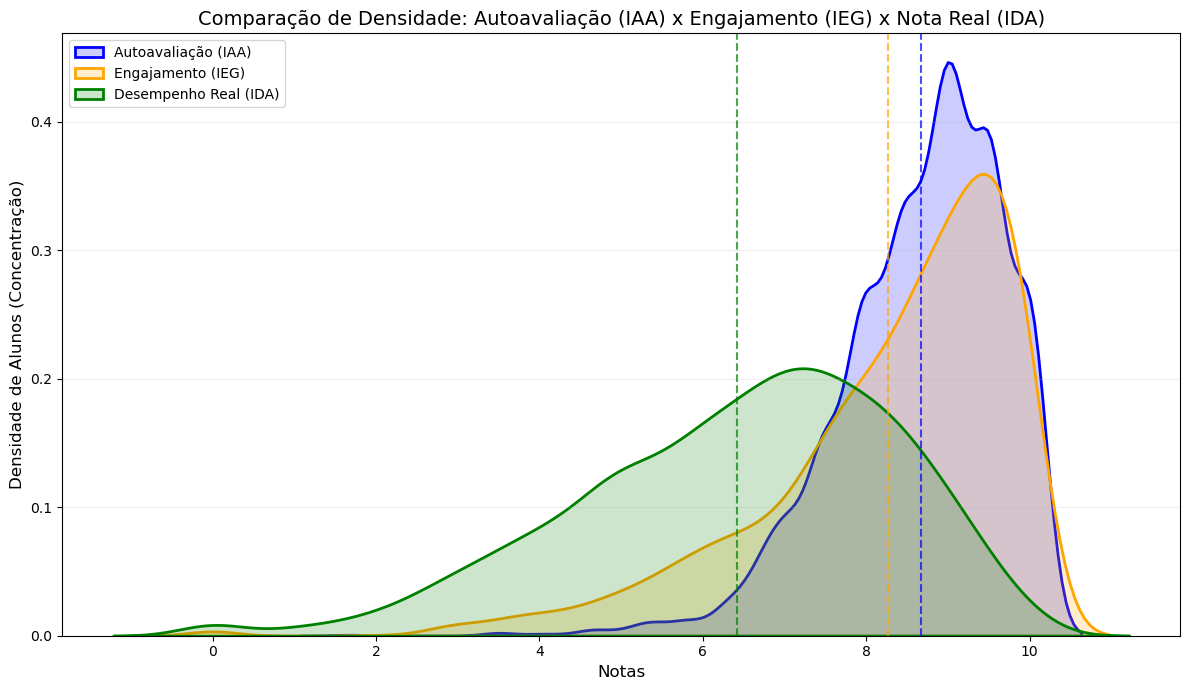

Médias -> IAA: 8.67 | IEG: 8.27 | IDA: 6.42


In [100]:
# ---------------------------------------------------------
# GERAÇÃO DO GRÁFICO DE DENSIDADE (KDE) TRIPLO
# ---------------------------------------------------------

plt.figure(figsize=(12, 7))

# IAA - Azul
sns.kdeplot(df_Questao4['iaa'], fill=True, label='Autoavaliação (IAA)', color='blue', alpha=0.2, linewidth=2)

# IEG - Laranja
sns.kdeplot(df_Questao4['ieg'], fill=True, label='Engajamento (IEG)', color='orange', alpha=0.2, linewidth=2)

# IDA - Verde
sns.kdeplot(df_Questao4['ida'], fill=True, label='Desempenho Real (IDA)', color='green', alpha=0.2, linewidth=2)

# Adicionando Linhas Verticais para as Médias (Tracejadas)
plt.axvline(df_Questao4['iaa'].mean(), color='blue', linestyle='--', alpha=0.7)
plt.axvline(df_Questao4['ieg'].mean(), color='orange', linestyle='--', alpha=0.7)
plt.axvline(df_Questao4['ida'].mean(), color='green', linestyle='--', alpha=0.7)

# Configurações Visuais
plt.title('Comparação de Densidade: Autoavaliação (IAA) x Engajamento (IEG) x Nota Real (IDA)', fontsize=14)
plt.xlabel('Notas', fontsize=12)
plt.ylabel('Densidade de Alunos (Concentração)', fontsize=12)
#plt.xlim(0, 11) # retirar as notas negativas ou > 10
plt.legend(title='', loc='upper left')
plt.grid(axis='y', alpha=0.2) 

plt.tight_layout()
plt.show()

# Imprimir as médias para conferência
print(f"Médias -> IAA: {df_Questao4['iaa'].mean():.2f} | IEG: {df_Questao4['ieg'].mean():.2f} | IDA: {df_Questao4['ida'].mean():.2f}")

### Grafico de densidade

Podemos observar que a comparação da autoavaliação (IAA) x nota real (IDA), existe grandes diferenças, conforme a curva Azul (IAA) e laranja (IEG): Identificamos que elas andam juntas, os picos estão quase no mesmo lugar (entre 8 e 9). 
Seria possivel fazer a seguinte interpretação: o aluno se avalia (Azul) baseado no quanto ele se engaja (Laranja).

Curva Verde (IDA): Ela está nitidamente deslocada para a esquerda, com um pico muito menor (perto de 6,5) e mais espalhada.

Médias Calculadas:

Autoavaliação (IAA): 8,67
Engajamento (IEG): 8,27
Nota Real (IDA): 6,42

A proximidade de 8,67 com 8,27 (apenas 0,4 de diferença) contrasta com a nota real de 6,42.

In [101]:
# Correlação de Pearson
corr_iaa_ida = df_Questao4['iaa'].corr(df_Questao4['ida'])
corr_iaa_ieg = df_Questao4['iaa'].corr(df_Questao4['ieg'])

print(f"Correlação IAA x IDA: {corr_iaa_ida:.2f}")
print(f"Correlação IAA x IEG: {corr_iaa_ieg:.2f}")


Correlação IAA x IDA: 0.13
Correlação IAA x IEG: 0.16


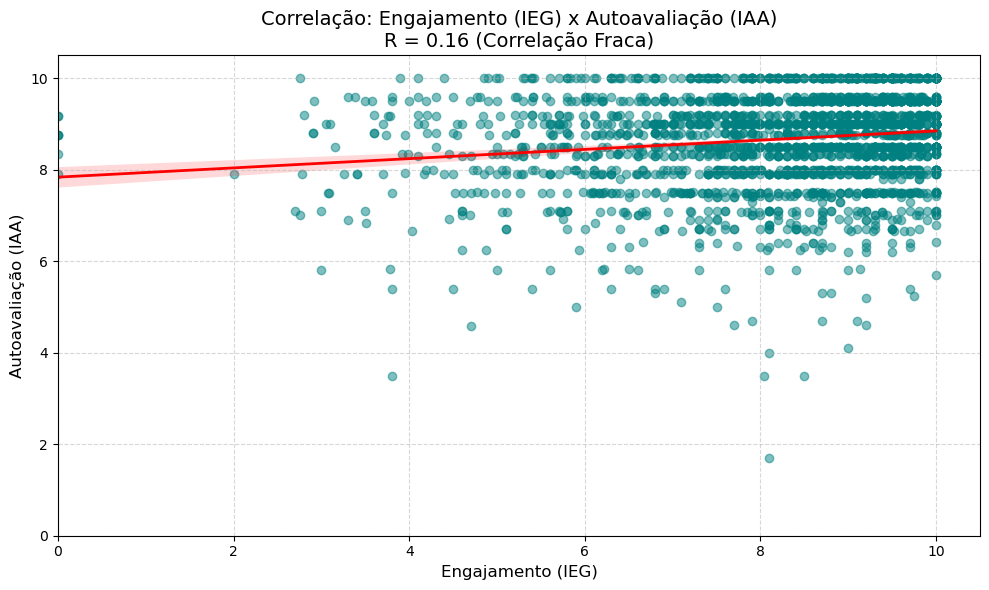

In [102]:
plt.figure(figsize=(10, 6))

# regplot desenha os pontos e a linha de tendência automaticamente
sns.regplot(
    x='ieg', 
    y='iaa', 
    data=df_Questao4, 
    scatter_kws={'alpha': 0.5, 'color': 'teal'}, # Pontos transparentes e azul-petróleo
    line_kws={'color': 'red', 'linewidth': 2}    # Linha de tendência vermelha
)

# Configurações do Layout
plt.title(f'Correlação: Engajamento (IEG) x Autoavaliação (IAA)\nR = {corr_iaa_ieg:.2f} (Correlação Fraca)', fontsize=14)
plt.xlabel('Engajamento (IEG)', fontsize=12)
plt.ylabel('Autoavaliação (IAA)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 10.5)
plt.ylim(0, 10.5)

plt.tight_layout()
plt.show()

Apesar de as curvas de densidade de IAA e IEG serem parecidas e as médias serem próximas (8,67 e 8,27), a correlação estatística mostra que não existe uma regra linear direta entre elas.

Podemos observar como os pontos estão espalhados por todo o gráfico, sem formar uma linha diagonal clara. Isso confirma a correlação baixa.

Concentração no Topo: Há uma grande massa de alunos no canto superior direito (Engajamento alto e Autoavaliação alta), mas também há muitos alunos com engajamento médio que se dão nota máxima (pontos no topo, meio).

Já a linha de tendência (vermelha) está levemente inclinada para cima, confirmando que existe uma relação positiva, mas ela é muito sutil.

## 🎯 Resposta final questão 4:

As percepções dos alunos sobre si mesmos na autoavaliação (IAA) não são coerentes com o seu desempenho de nota real (IDA), demonstrando uma clara superestimação das próprias capacidades. 
Em relação ao engajamento (IEG), embora haja uma similaridade na distribuição das notas (proximas de 8,5), a correlação estatística entre elas é bem fraca (0,16).

Podemos identificar no gráfico de densidade:
A curva azul (Autoavaliação - IAA) e a curva laranja (Engajamento - IEG) apresentam um comportamento muito similar, ambas fortemente assimetrias à esquerda, com picos de concentração (moda) situados entre as notas 8,5 e 9,5. Em contraste, a curva verde (Desempenho Real - IDA) é mais "achatada" (maior desvio padrão) e possui seu centro de massa deslocado significativamente para a esquerda (aprox. 6,5). Isso indica que, enquanto a vasta maioria dos alunos se avalia com notas boas o engajamento está proximo, mas as notas reais são substancialmente inferiores e mais distribuídas

Já o gráfico de dispersão apresenta uma nuvem de pontos concentrada no quadrante superior direito (alto engajamento e alta autoavaliação). No entanto, a linha de tendência vermelha possui uma inclinação muito suave e o coeficiente de correlação é de apenas 0,16 (muito baixo).

Os dados sugerem um cenário de calibragem imprecisa por parte dos alunos. A percepção de competência (IAA) e de esforço (IEG) está desconectada dos resultados concretos (IDA). O aluno "sente" que está aprendendo e se dedicando em um nível alto (faixa 8,5), mas a realidade avaliativa mostra um desempenho mediano (faixa 6,5).


Sugestão que ocorreu na nossa reuniao (adicionar por exemplo Fase):

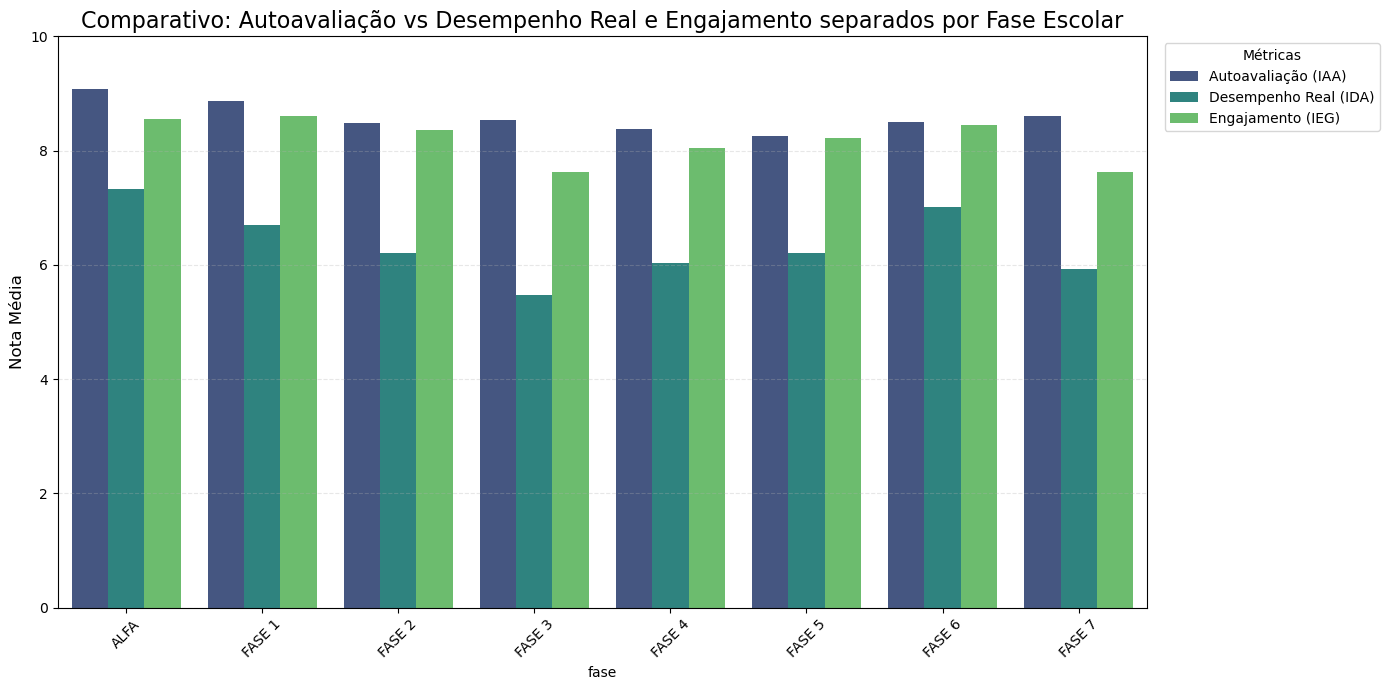

In [103]:
# 4. Calcular as médias de cada indicador por Fase
# Agrupamos pela coluna 'fase' e tiramos a média de IAA, IDA e IEG
medias_por_fase = df_Questao4.groupby('fase')[['iaa','ida','ieg']].mean().reset_index()

# 5. Transformar os dados para o formato "longo" (Melt)
# O Seaborn precisa que os dados estejam empilhados para criar as barras agrupadas (hue)
df_melted = medias_por_fase.melt(id_vars='fase', 
                                 var_name='Indicador', 
                                 value_name='Nota Média')

# 6. Renomear os indicadores para a legenda ficar bonita
mapa_nomes = {
    'iaa': 'Autoavaliação (IAA)', 
    'ida': 'Desempenho Real (IDA)', 
    'ieg': 'Engajamento (IEG)'
}
df_melted['Indicador'] = df_melted['Indicador'].map(mapa_nomes)

# 7. Configurar e Plotar o Gráfico
plt.figure(figsize=(14, 7)) # Tamanho da figura (Largura, Altura)

sns.barplot(
    data=df_melted, 
    x='fase', 
    y='Nota Média', 
    hue='Indicador', 
    palette='viridis' # Paleta de cores (pode trocar por 'deep', 'muted', etc)
)

# Customização do Layout
plt.title('Comparativo: Autoavaliação vs Desempenho Real e Engajamento separados por Fase Escolar', fontsize=16)
plt.ylabel('Nota Média', fontsize=12)
# plt.xlabel('Fase Escolar', fontsize=12)
plt.xticks(rotation=45) # Gira os nomes das fases para facilitar leitura
plt.ylim(0, 10) # Garante que o eixo Y vá de 0 a 10
plt.grid(axis='y', linestyle='--', alpha=0.3) # Linhas de grade suaves
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Métricas') # Legenda fora do gráfico

plt.tight_layout() # Ajusta margens automaticamente
plt.show()

Há um padrão claro e consistente em todas as fases: os alunos sistematicamente avaliam suas próprias capacidades "IAA" (barras azuis) muito acima do que suas notas reais "IDA" (barras verde-escuras) demonstram. 

A autoavaliação flutua muito pouco (sempre entre 8.0 e 9.0), enquanto a nota real sofre variações maiores e é sempre inferior.

Já a autoavaliação "IAA" (azul) caminha muito mais próxima do engajamento "IEG" (verde-claro) do que da nota real. 
Isto sugere que os alunos podem estar confundindo esforço com competência. 

Provavelmente o raciocínio do aluno é: "Eu participo e me esforço (possuo engajamento - IEG), logo, eu sou um bom aluno (autoavaliação - IAA alta)", mesmo que isso não se traduza em notas reais (IDA).